In [9]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
data = xr.open_dataset("/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/output/merged_nc_files/HS_SWE_dataset.nc")

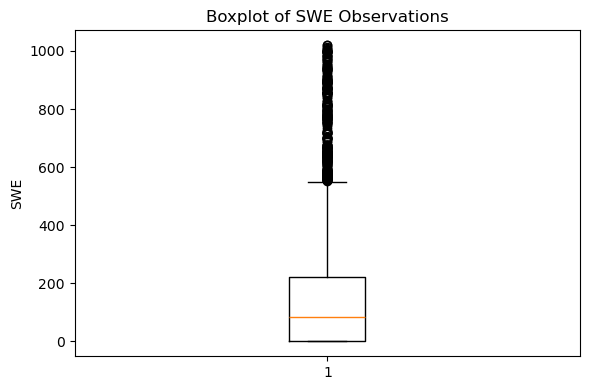

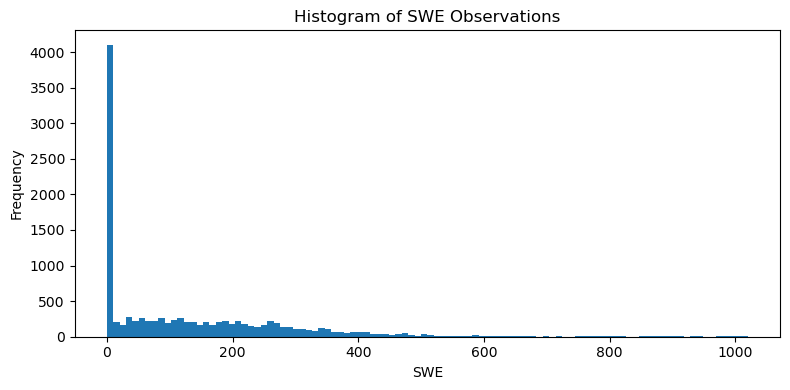

In [13]:


# Drop NaNs and flatten
swe = data['swe_obs'].stack(all_dims=data['swe_obs'].dims)
swe = swe.dropna('all_dims')

# Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(swe.values)
plt.title('Boxplot of SWE Observations')
plt.ylabel('SWE')
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(8, 4))
plt.hist(swe.values, bins=100)
plt.title('Histogram of SWE Observations')
plt.xlabel('SWE')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

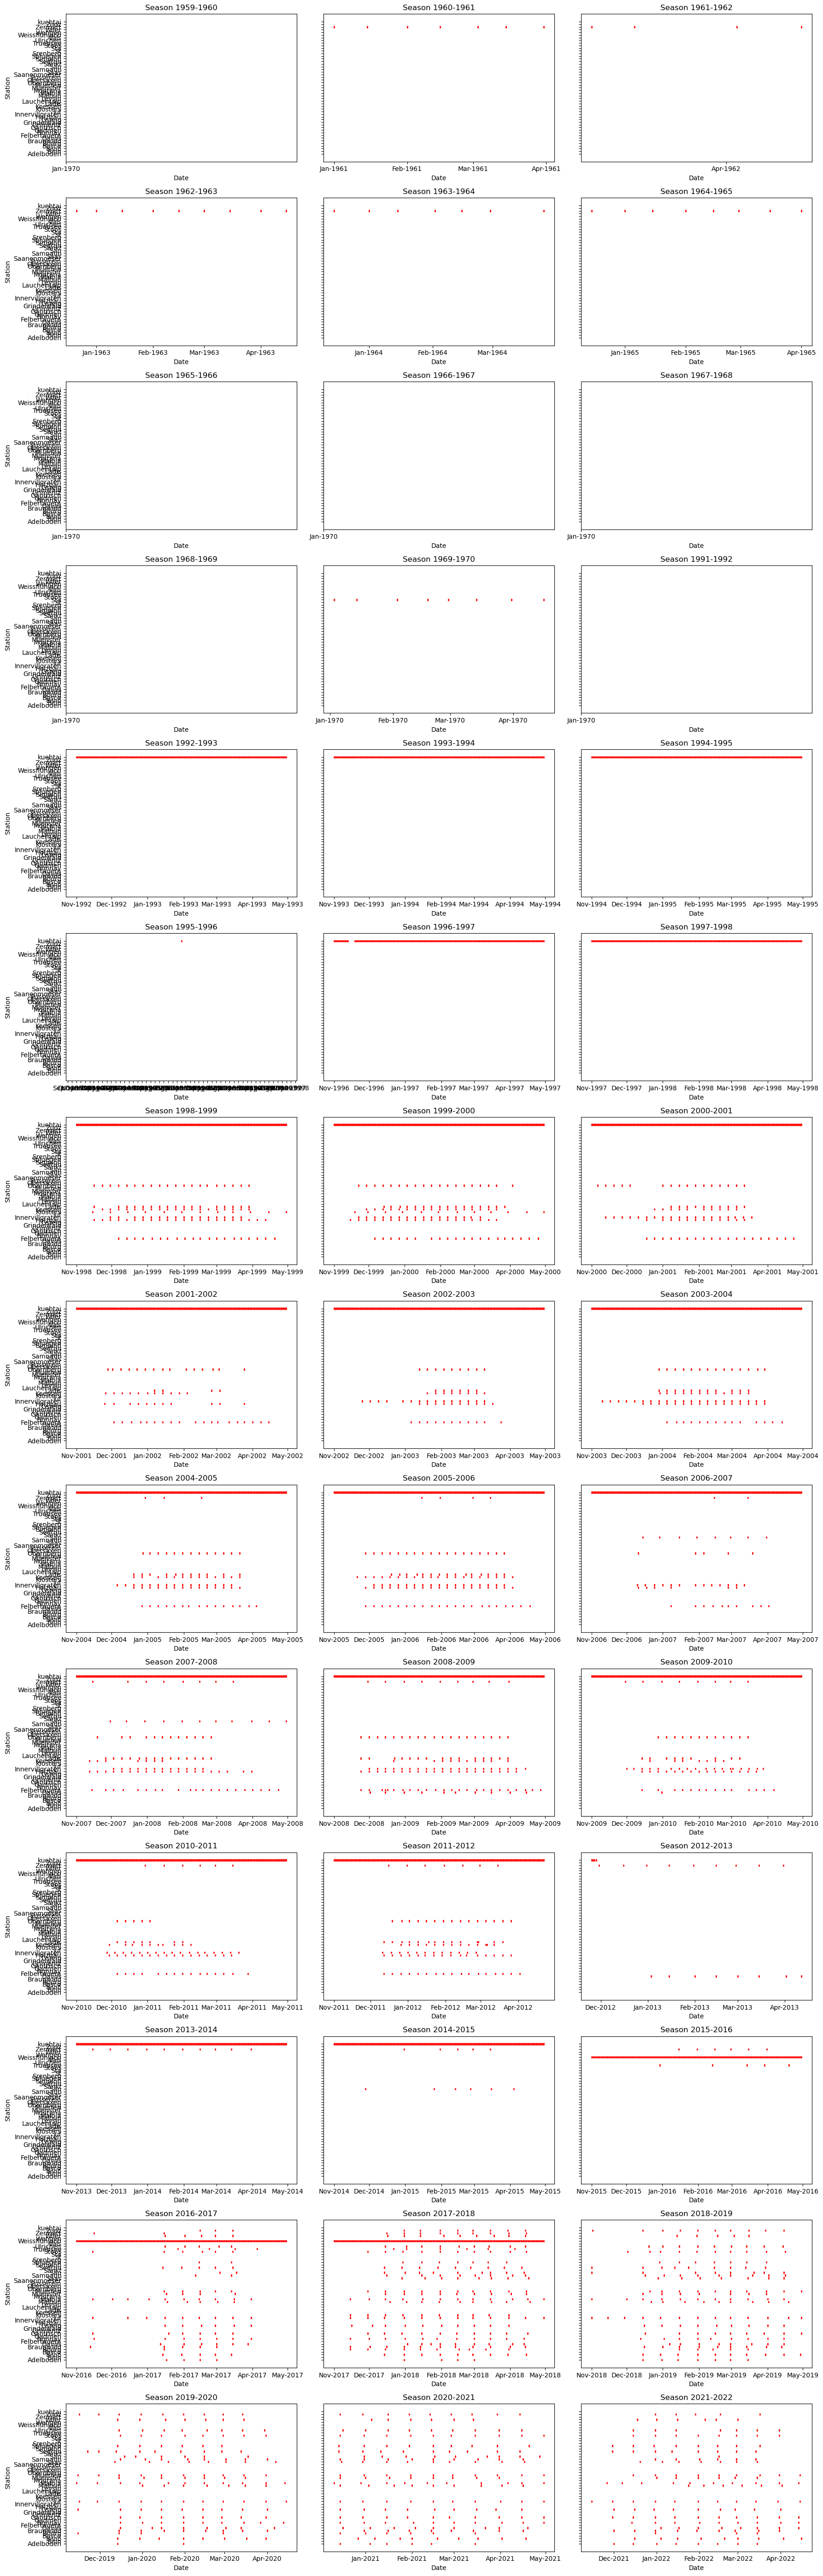

In [15]:
import matplotlib.dates as mdates

# Get all available seasons (Nov 1 – May 1) in the dataset
years = np.unique([t.year if t.month >= 11 else t.year - 1 for t in pd.to_datetime(data['time'].values)])
seasons = [(y, y + 1) for y in years if y + 1 <= pd.to_datetime(data['time'].values).max().year]

nrows = int(np.ceil(len(seasons) / 3))
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), sharey=True)
axes = axes.flatten()

stations = data['station'].values

for i, (start_year, end_year) in enumerate(seasons):
    ax = axes[i]
    season_start = pd.Timestamp(f"{start_year}-11-01")
    season_end = pd.Timestamp(f"{end_year}-05-01")
    for idx, station in enumerate(stations):
        df = data.sel(station=station).to_dataframe().reset_index()
        mask = (df['time'] >= season_start) & (df['time'] < season_end)
        df_season = df.loc[mask]
        obs_mask = ~df_season['swe_obs'].isna()
        obs_dates = df_season.loc[obs_mask, 'time']
        ax.vlines(obs_dates, idx - 0.4, idx + 0.4, color='red', linewidth=2)
    ax.set_yticks(range(len(stations)))
    ax.set_yticklabels(stations)
    ax.set_xlabel('Date')
    ax.set_title(f'Season {start_year}-{end_year}')
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
    if i % ncols == 0:
        ax.set_ylabel('Station')
    else:
        ax.set_ylabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
import os

# Ensure output directory exists
output_dir = "/Users/jakobwerkgarner/code/mt_dsnow/par_sens/seasonal_measurments/data"
os.makedirs(output_dir, exist_ok=True)

for station in data['station'].values:

    # Extract station data
    df = data.sel(station=station).to_dataframe().reset_index()
    df = df[['time', 'hs', 'swe_obs']]

    # Define season (Nov 1 – May 1)
    df['season_start_year'] = df['time'].apply(
        lambda x: x.year if x.month >= 11 else x.year - 1
    )
    df['season'] = (
        df['season_start_year'].astype(str) + "_" +
        (df['season_start_year'] + 1).astype(str)
    )

    # Process each season
    for season, group in df.groupby('season'):

        start_year, end_year = season.split('_')
        start = pd.Timestamp(f"{start_year}-11-01")
        end   = pd.Timestamp(f"{end_year}-05-01")

        season_df = group[(group['time'] >= start) & (group['time'] < end)]

        if season_df.empty:
            continue

        # Only use seasons with more than 4 swe_obs values
        if season_df['swe_obs'].count() <= 4:
            continue

        # -------------------------------
        # CONTINUITY CHECK
        # - hs == 0 is allowed
        # - NaNs are NOT allowed
        # -------------------------------
        if season_df['hs'].isna().any():
            continue

        # Optional: ensure daily continuity (recommended)
        full_index = pd.date_range(start=start, end=end - pd.Timedelta(days=1), freq='D')
        season_df = season_df.set_index('time').reindex(full_index).reset_index()
        season_df.rename(columns={'index': 'time'}, inplace=True)

        # After reindexing: still no NaNs allowed in hs
        if season_df['hs'].isna().any():
            continue

        # Save CSV
        filename = f"{station}_{season}.csv"
        filepath = os.path.join(output_dir, filename)

        season_df[['time', 'hs', 'swe_obs']].to_csv(filepath, index=False)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (97784175.py, line 4)